# 新闻文本分类

通过机器学习的方法对新闻进行文本分类

## 一、数据集划分

初始数据集为三千条新闻并附带类别标签，包括体育，家居，房产，教育，科技，财经共六类，每类各五百条新闻。我们要将数据集划分为训练集，测试集和测试集标签。训练集包括每类各4000条新闻及其标签，测试集包括每类剩余的1000条新闻文本，测试集标签为测试集每条新闻文本的对应分类标签

In [ ]:
def split_data(): 
    # 定义要提取的行号范围，规定每一类新闻提取4000条
    train_ranges = [
        (0, 4000),      # 1-4000
        (5000, 9000),   # 5001-9000
        (10000, 14000), # 10001-14000
        (15000, 19000), # 15001-19000
        (20000, 24000), # 20001-24000
        (25000, 29000)  # 25001-29000
    ]
    
    # 读取原始文件
    with open('filtered_cnews.train.txt', 'r', encoding='utf-8') as f:
        lines = f.readlines()
    
    # 用于存储训练集的行
    train_lines = []
    # 用于存储测试集的行
    test_lines = []
    # 用于存储测试集的标签
    test_labels = []
    
    # 遍历所有行
    for i, line in enumerate(lines):
        # 检查当前行是否在训练集范围内
        is_train = False
        for start, end in train_ranges:
            if start <= i < end:
                is_train = True
                break
        
        # 根据结果将行添加到相应的列表中
        if is_train:
            train_lines.append(line)
        else:
            # 提取前两个字符作为标签
            label = line[:2]
            # 删除每行前三个字符后添加到测试集
            test_lines.append(line[3:])
            # 保存标签
            test_labels.append(label)
    
    # 写入训练集文件
    with open('train.txt', 'w', encoding='utf-8') as f:
        f.writelines(train_lines)
    
    # 写入测试集文件
    with open('test.txt', 'w', encoding='utf-8') as f:
        f.writelines(test_lines)
        
    # 写入测试集标签文件
    with open('test_labels.txt', 'w', encoding='utf-8') as f:
        f.writelines(label + '\n' for label in test_labels)

# 执行函数
if __name__ == '__main__':
    split_data()

## 二、文本分类

1.停用词表。部分词语如数字、“是”、“的”、语气词等对文本意义关联不大，需要一个停用词表去除训练集中的这些词。我采用的是https://blog.csdn.net/dilifish/article/details/117885706

2.文本预处理。包括去除每条新闻最后的作者或日期后缀，去除符号和空格，统一全角字符转半角，jieba进行中文分词处理，去除可能的乱码等。

3.文本分类。将文本转换为TF-IDF特征进行特征提取，采用朴素贝叶斯分类器进行训练，随后进行交叉验证，在完整训练集上训练模型，随后进行测试集预测，将预测结果写入文件，在保存预测结果后评估准确性。

4.结果可视化。读取预测结果和真实标签，计算总体准确率和每一类的准确率，打印计算报告。绘制条形图和混淆矩阵图。

In [ ]:
import jieba
import numpy as np
import re
import string
import os
import logging
import seaborn as sns
import matplotlib.pyplot as plt
from typing import List
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report


def load_stopwords(filename: str = "stoplist.txt") -> set:
    """
    加载停用词表
    
    参数:
        filename: 停用词表文件名，默认为'stoplist.txt'
    返回:
        包含停用词的集合
    """
    # 获取当前文件所在目录的路径
    current_dir = os.path.dirname(os.path.abspath(__file__))
    # 构建停用词表的完整路径
    stopwords_path = os.path.join(current_dir, filename)
    
    try:
        with open(stopwords_path, 'r', encoding='utf-8') as f:
            return {line.strip() for line in f if line.strip()}
    except FileNotFoundError:
        print(f"警告：未找到停用词表文件 {stopwords_path}")
        return set()
    except UnicodeDecodeError:
        print(f"警告：文件编码错误 {stopwords_path}")
        return set()
    except Exception as e:
        print(f"警告：加载停用词表时发生错误: {str(e)}")
        return set()

def load_data(train_path='train.txt', test_path='test.txt'):
    """
    加载训练集和测试集数据。
    """
    # 获取当前文件所在目录的路径
    current_dir = os.path.dirname(os.path.abspath(__file__))
    # 构建完整文件路径
    train_path = os.path.join(current_dir, train_path)
    test_path = os.path.join(current_dir, test_path)

    try:
        # 加载训练集
        train_texts = []
        train_labels = []
        with open(train_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if not line:  # 跳过空行
                    continue
                parts = line.split(maxsplit=1)  # 使用 maxsplit 避免误分割
                if len(parts) != 2:  # 检查格式是否正确
                    print(f"警告：训练集中发现格式错误的行：{line}")
                    continue
                label, text = parts
                train_texts.append(text)
                train_labels.append(label)

        # 加载测试集
        test_texts = []
        with open(test_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if line:  # 跳过空行
                    test_texts.append(line)

        if not train_texts or not test_texts:
            print("警告：训练集或测试集为空！")
            
        return train_texts, train_labels, test_texts

    except FileNotFoundError as e:
        print(f"错误：找不到文件 - {e.filename}")
        return [], [], []
    except UnicodeDecodeError:
        print("错误：文件编码不是UTF-8格式")
        return [], [], []

def chinese_word_cut(text: str) -> str:
    """
    对中文文本进行预处理和分词
    
    参数:
        text: 输入的文本字符串
    返回:
        处理后的分词结果字符串
    """
    # 1. 移除末尾的英文括号内容
    text = re.sub(r'\([^)]*\)$', '', text)  # 移除末尾的英文括号及其内容
    text = re.sub(r'\（[^）]*\）$', '', text)  # 移除末尾的中文括号及其内容
    
    # 2. 基础文本清理
    text = text.strip()
    
    # 3. 统一全角转半角
    def full_to_half(text):
        n = []
        for char in text:
            num = ord(char)
            if num == 0x3000:  # 全角空格直接转换
                num = 32
            elif 0xFF01 <= num <= 0xFF5E:  # 全角字符范围
                num -= 0xFEE0
            n.append(chr(num))
        return ''.join(n)
    
    text = full_to_half(text)
    
    # 4. 去除多余空白字符
    text = re.sub(r'\s+', ' ', text)
    
    # 5. 处理标点符号
    # 定义中文标点和英文标点
    chinese_punc = '！？｡。＂＃＄％＆＇（）＊＋，－／：；＜＝＞＠［＼］＾＿｀｛｜｝～｟｠｢｣､、〃》「」『』【】〔〕〖〗〘〙〚〛〜〝〞〟〰〾〿–—''‛""„‟…‧﹏'
    english_punc = string.punctuation

    # 先处理英文标点：将其替换为空格
    for punc in english_punc:
        text = text.replace(punc, ' ')
    
    # 处理中文标点：在标点前后添加空格
    for punc in chinese_punc:
        text = text.replace(punc, f' {punc} ')

    # 6. 清理多余空格
    text = re.sub(r'\s+', ' ', text).strip()
    
    # 7. 分词处理
    words = jieba.cut(text)
    
    # 8. 过滤处理
    filtered_words = []
    for word in words:
        # 去除空白词
        if word.isspace():
            continue
        # 检测可能的乱码
        if any(ord(char) > 0xFFFF for char in word):
            continue
        filtered_words.append(word)
    
    # 9. 返回处理后的结果
    return ' '.join(filtered_words)

def evaluate_predictions():
    """
    评估预测结果并进行可视化
    """
    plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
    plt.rcParams['axes.unicode_minus'] = False    # 用来正常显示负号
    
    # 读取预测结果和真实标签
    with open('predictions.txt', 'r', encoding='utf-8') as f:
        predictions = [line.strip() for line in f]
    with open('test_labels.txt', 'r', encoding='utf-8') as f:
        true_labels = [line.strip() for line in f]
    
    # 计算准确率
    accuracy = accuracy_score(true_labels, predictions)
    print(f'\n总体准确率: {accuracy:.4f}')
    
    # 打印详细分类报告
    print('\n分类报告:')
    print(classification_report(true_labels, predictions))
    
    # 计算混淆矩阵
    cm = confusion_matrix(true_labels, predictions)
    
    # 获取唯一的标签类别
    labels = sorted(set(true_labels))
    
    # 创建混淆矩阵的热力图
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title('预测结果混淆矩阵')
    plt.xlabel('预测标签')
    plt.ylabel('真实标签')
    plt.savefig('confusion_matrix.png')
    plt.close()
    
    # 计算每个类别的准确率
    class_accuracy = {}
    for label in labels:
        mask = [t == label for t in true_labels]
        correct = sum(p == t for p, t in zip(predictions, true_labels) if t == label)
        total = sum(mask)
        class_accuracy[label] = correct / total
    
    # 绘制条形图显示每个类别的准确率
    plt.figure(figsize=(10, 6))
    plt.bar(class_accuracy.keys(), class_accuracy.values())
    plt.title('各类别预测准确率')
    plt.xlabel('类别')
    plt.ylabel('准确率')
    plt.xticks(rotation=45)
    for i, v in enumerate(class_accuracy.values()):
        plt.text(i, v, f'{v:.3f}', ha='center', va='bottom')
    plt.tight_layout()
    plt.savefig('class_accuracy.png')
    plt.close()


def main():
    # 设置日志
    import logging
    logging.basicConfig(
        level=logging.INFO,
        format='%(asctime)s - %(levelname)s - %(message)s'
    )
    logger = logging.getLogger(__name__)
    
    # 加载数据
    logger.info("正在加载数据...")
    train_texts, train_labels, test_texts = load_data()
    
    # 分词处理
    logger.info("正在进行分词...")
    train_texts_cut = [chinese_word_cut(text) for text in train_texts]
    test_texts_cut = [chinese_word_cut(text) for text in test_texts]

    # 加载停用词表
    stopwords = load_stopwords()
    
    # 特征提取 - 将文本转换为TF-IDF特征
    logger.info("正在提取特征...")
    tfidf_vectorizer = TfidfVectorizer(
        max_features=5000,  # 最多使用5000个特征
        min_df=2,          # 至少出现2次的词才被考虑
        max_df=0.95,       # 出现在超过95%文档中的词被忽略
        stop_words=list(stopwords),  # 将set转换为list
        token_pattern=r'(?u)\b\w+\b'  # 支持中文词语
    )
    
    # 训练集特征转换
    train_features = tfidf_vectorizer.fit_transform(train_texts_cut)
    # 测试集特征转换
    test_features = tfidf_vectorizer.transform(test_texts_cut)
    
    # 训练朴素贝叶斯分类器
    logger.info("正在训练模型...")
    clf = MultinomialNB(alpha=0.1)  # alpha是平滑参数
    
    # 进行交叉验证评估
    from sklearn.model_selection import cross_val_score
    logger.info("正在进行交叉验证...")
    cv_scores = cross_val_score(clf, train_features, train_labels, cv=5)
    logger.info(f"交叉验证得分: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")
    
    # 在完整训练集上训练模型
    clf.fit(train_features, train_labels)
    
    # 预测测试集
    logger.info("正在预测...")
    predictions = clf.predict(test_features)
    
    # 将预测结果写入文件
    logger.info("正在保存预测结果...")
    with open('predictions.txt', 'w', encoding='utf-8') as f:
        for pred in predictions:
            f.write(pred + '\n')
    
    logger.info("处理完成！预测结果已保存到 predictions.txt")

    # 在保存预测结果后添加评估
    logger.info("正在评估预测结果...")
    evaluate_predictions()
    logger.info("评估完成！可视化结果已保存为confusion_matrix.png和class_accuracy.png")

if __name__ == '__main__':
    main()

## 三、结果展示

1.
总体准确率: 0.9038

分类报告:
              precision    recall  f1-score   support

          体育       1.00      0.98      0.99      1000
          家居       0.91      0.69      0.79      1000
          房产       0.79      0.93      0.85      1000
          教育       0.93      0.91      0.92      1000
          科技       0.88      0.91      0.90      1000
          财经       0.93      0.99      0.96      1000
         accuracy                      0.90      6000
         macro avg     0.91      0.90      0.90      6000
        weighted avg    0.91      0.90      0.90      6000
        
2.条形图
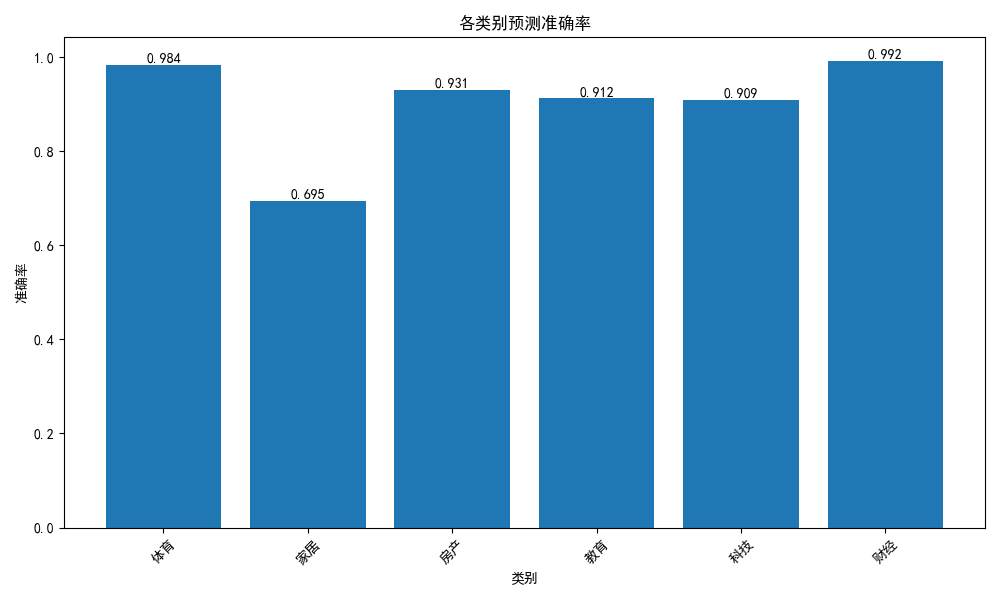

3.混淆矩阵图
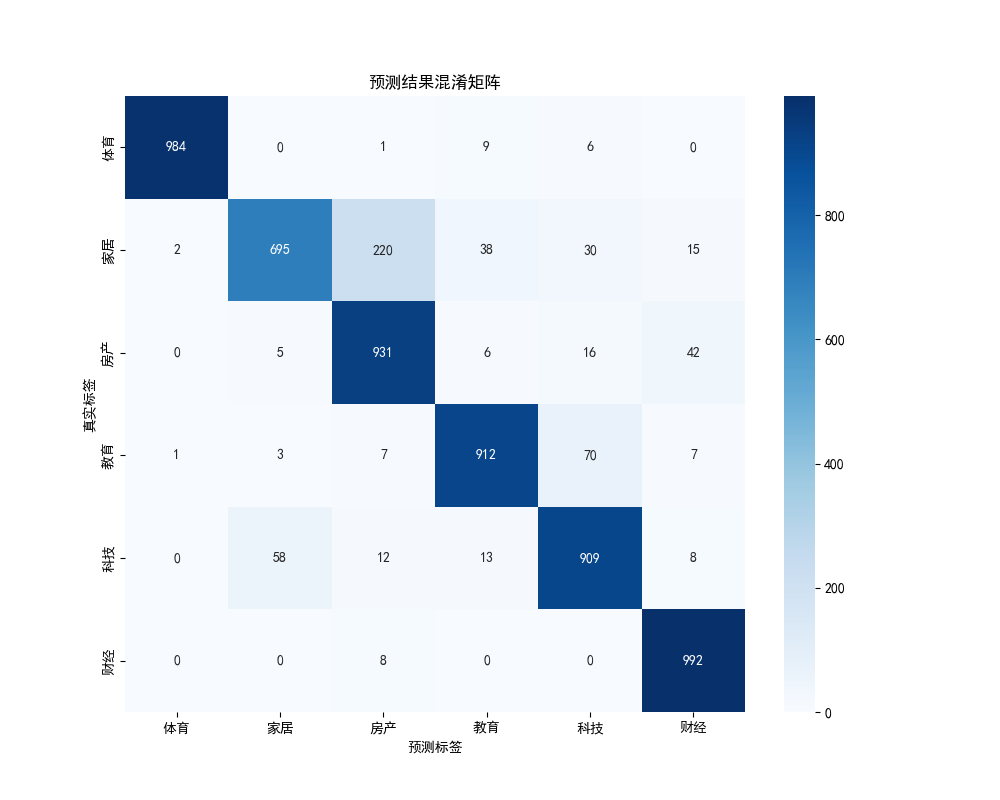